**PROGETTO 2**

Questo modello Machine Learning oriented, si pone come obiettivo quello di allenare un classificatore attraverso un processo di train esplicito. Il Dataset da me scelto è "Hello-SimpleAI/HC3", composto da un testo che sarebbero le "questions", ovvero i questiti e le labels che invece sono le "anwers", le risposte date da un'intelligenza artificiale, in questo caso Chatgpt e gli esseri umani. Il Task è quello di prevedere se il modello è in grado di capire se a rispodere è l'AI o un essere umano.

In [ ]:
!pip install datasets
!pip install pandas
!pip install scikit-learn
!pip install sentence-transformers
!pip install numpy
!pip install spacy
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.31.0
    Uninstalling requests-2.31.0:
      Successfully uninstalled requests-2.31.0
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      Successfully uninstalled pyarrow-14.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.

In [ ]:
from datasets import load_dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import spacy
import en_core_web_sm
from collections import defaultdict

**DATA PRE-PROCESSING:**Per far si che il lavoro possa iniziare, carico il Dataset cosi da poterlo visualizzare nella sua interezza e i quindi visualizzare il modo in cui è strutturato e suddiviso. Una volta appreso che non è splittato, lo divido in train e data così da potere fare l'addestramento più avanti.
Per non avere problemi durante la separazione dei dati in train e test, trasformo le labels in stringhe e attraverso la libreria Sklearn importo "train_test_split" che applicata ai miei dati li dividerà automaticamente in test e train. Per facilitare il calcolo dei dati, ne prendo meno e per fare si che essi vengano estratti a caso applico un sample.




In [ ]:
dataset = load_dataset('Hello-SimpleAI/HC3', 'all')
print(dataset)

data = pd.DataFrame(dataset['train'])[['question', 'human_answers', 'chatgpt_answers']]
data['human_answers'] = data['human_answers'].astype(str)
data['chatgpt_answers'] = data['chatgpt_answers'].astype(str)

train_data, test_data = train_test_split(data, test_size=0.33, random_state=42)

train = train_data.sample(16000)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/24322 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'human_answers', 'chatgpt_answers', 'source'],
        num_rows: 24322
    })
})


Procedo con la craezione di una nuova label che unisca 'human_answers' e 'chat_answers' in 'answers', dove 1 corrisponde a human e 0 a chatgpt. Utilizzo la funzione rename per cambiare nome alla label e poi concat per unirle in un'unica colonna.
Creato un nuovo Dataframe lo splitto un'altra volta in train e test.

In [ ]:

data_human = data[['question', 'human_answers']].copy()
data_human['label'] = 1
data_human.rename(columns={'human_answers': 'answer'}, inplace=True)


data_chatgpt = data[['question', 'chatgpt_answers']].copy()
data_chatgpt['label'] = 0
data_chatgpt.rename(columns={'chatgpt_answers': 'answer'}, inplace=True)

labels = pd.concat([data_human, data_chatgpt], ignore_index=True)
data_new= labels.sample(16000)
print("data_new: ",data_new)


data2 = data_new
train_data2, test_data2 = train_test_split(data2, test_size=0.33, random_state=42)
print("splittato: ",data2)
#print("Train Data:\n", train_data)
#print("Test Data:\n", test_data2)


data_new:                                                  question  \
20341  Possible to use balance transfers to avoid int...   
782    Why do people trace the lineage of Jesus back ...   
7184   Those fan shaped math equations from Good Will...   
39919  How do snipers avoid being detected from their...   
3661   How can people buy and sell land if they did n...   
...                                                  ...   
12432  When you 're sick and can only breathe out of ...   
33623  Why commercial breaks have more volume than th...   
34806  What are the disadvantages of not owning a cre...   
11071  How are emulators written ? I only have very b...   
37784  Why I need 2.5 GB free to install an iOS updat...   

                                                  answer  label  
20341  ["Sure of course you can do balance transfers ...      1  
782    ["Ancient people did n't know anything about g...      1  
7184   ['[ Numberphile actually made a good video abo...      1  
3991

**CALCOLO DEL POS TAGGING E CREAZIONE DEI DIZIONARI** In questa parte del mio codice utilizzo una funzione che mi crea un dizionario, comprendente i POS tags possibili, che metto come keys e un contatore a 0 per ogni volta che essi vengono trovati in ogni sentence del testo. A questo punto applico la mia funzione sia ai dati di train che a quelli di data. Finite entrambe le liste di dizionari li unisco in un unico set, così da non avere ripetizioni e soprattutto per fare si che vengano trovate tutti i possibili POS tags nei dati di train e test.

In [ ]:
nlp = spacy.load('en_core_web_sm')
def count_pos_tags(text):
    count_POS_answer = {}
    doc = nlp(text)
    for word in doc:
        if word.pos_ not in count_POS_answer:
            count_POS_answer[word.pos_] = 1
        else:
            count_POS_answer[word.pos_] += 1
    return count_POS_answer

lista_diz = [count_pos_tags(text) for text in train_data2['answer']]
print("lista_train: ", lista_diz)

lista_diz_test = [count_pos_tags(text) for text in test_data2['answer']]
print("lista_test: ", lista_diz_test)

all_pos_tags = set(pos for d in lista_diz + lista_diz_test for pos in d.keys())




lista_train:  [{'X': 2, 'PUNCT': 17, 'PRON': 12, 'AUX': 12, 'PART': 9, 'ADJ': 22, 'VERB': 19, 'SCONJ': 8, 'NOUN': 30, 'NUM': 1, 'DET': 12, 'ADP': 14, 'CCONJ': 7, 'PROPN': 5, 'ADV': 9}, {'X': 1, 'PUNCT': 14, 'SCONJ': 4, 'PRON': 9, 'AUX': 8, 'VERB': 18, 'ADJ': 6, 'DET': 13, 'NOUN': 30, 'PART': 5, 'ADV': 8, 'ADP': 16, 'SYM': 2, 'NUM': 2, 'CCONJ': 4, 'PROPN': 1}, {'X': 7, 'PUNCT': 21, 'ADP': 11, 'DET': 12, 'VERB': 7, 'NOUN': 27, 'ADJ': 5, 'AUX': 6, 'CCONJ': 5, 'NUM': 10, 'PROPN': 3, 'SCONJ': 1, 'ADV': 1, 'SYM': 1}, {'X': 1, 'PUNCT': 27, 'VERB': 36, 'DET': 24, 'NOUN': 52, 'AUX': 25, 'ADJ': 27, 'ADP': 28, 'CCONJ': 13, 'PRON': 22, 'PART': 12, 'ADV': 11, 'NUM': 1, 'SCONJ': 4}, {'X': 1, 'PUNCT': 28, 'PRON': 16, 'AUX': 21, 'ADJ': 16, 'PART': 8, 'VERB': 25, 'ADP': 22, 'DET': 14, 'NOUN': 37, 'ADV': 20, 'SCONJ': 7, 'CCONJ': 6, 'PROPN': 2, 'NUM': 2}, {'X': 1, 'PUNCT': 17, 'PROPN': 10, 'AUX': 20, 'VERB': 31, 'SCONJ': 7, 'ADJ': 17, 'NOUN': 27, 'PRON': 20, 'ADV': 4, 'CCONJ': 7, 'DET': 22, 'ADP': 16, 'P

**TRASFORMAZIONE IN ARRAY** I dizionari creati non hanno la stessa dimenzione e per renderli della stessa lunghezza li trasformo in array, uno per il train da passare al MLPC e l'altro per test per la prediction.

In [ ]:
def dict_to_array(dict_list, all_pos_tags):
    array = []
    for d in dict_list:
        array.append([d.get(pos, 0) for pos in all_pos_tags])
    return np.array(array)

pos_array_train = dict_to_array(lista_diz, all_pos_tags)
print(pos_array_train)
pos_array_test = dict_to_array(lista_diz_test, all_pos_tags)

labels_train = np.array(train_data2['label'])


[[17  1  8 ... 22  9 14]
 [14  2  4 ...  6  5 16]
 [21 10  1 ...  5  0 11]
 ...
 [32  1  6 ... 26  6 22]
 [15  0  3 ... 17 13 13]
 [28  1  3 ...  8  6 17]]


**TRAINING OF THE MODEL** a questo punto passo al MLPClassifier i miei dati di train, e addestro il modello.

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(24000,), random_state=42)
mlp.fit(pos_array_train, labels_train)

MLPClassifier(hidden_layer_sizes=(24000,), random_state=42)

**VALIDATION** Calcolati i dati di train passo all' 'mlp.predict' i dati di test per fare le predictions.



In [ ]:
predictions = mlp.predict(pos_array_test)
print(predictions)

[0 0 1 ... 1 0 0]


**STATISTICS** Faccio il rapporto di classificazione.

              precision    recall  f1-score   support

     chatgpt       0.93      0.95      0.94      2691
       human       0.94      0.92      0.93      2589

    accuracy                           0.93      5280
   macro avg       0.93      0.93      0.93      5280
weighted avg       0.93      0.93      0.93      5280

report:  {'0': {'precision': 0.9270871308786001, 'recall': 0.9450018580453363, 'f1-score': 0.9359587780640413, 'support': 2691}, '1': {'precision': 0.9416633819471817, 'recall': 0.9227500965623793, 'f1-score': 0.9321108076472883, 'support': 2589}, 'accuracy': 0.9340909090909091, 'macro avg': {'precision': 0.9343752564128909, 'recall': 0.9338759773038579, 'f1-score': 0.9340347928556647, 'support': 5280}, 'weighted avg': {'precision': 0.9342344630787057, 'recall': 0.9340909090909091, 'f1-score': 0.9340719607517358, 'support': 5280}}


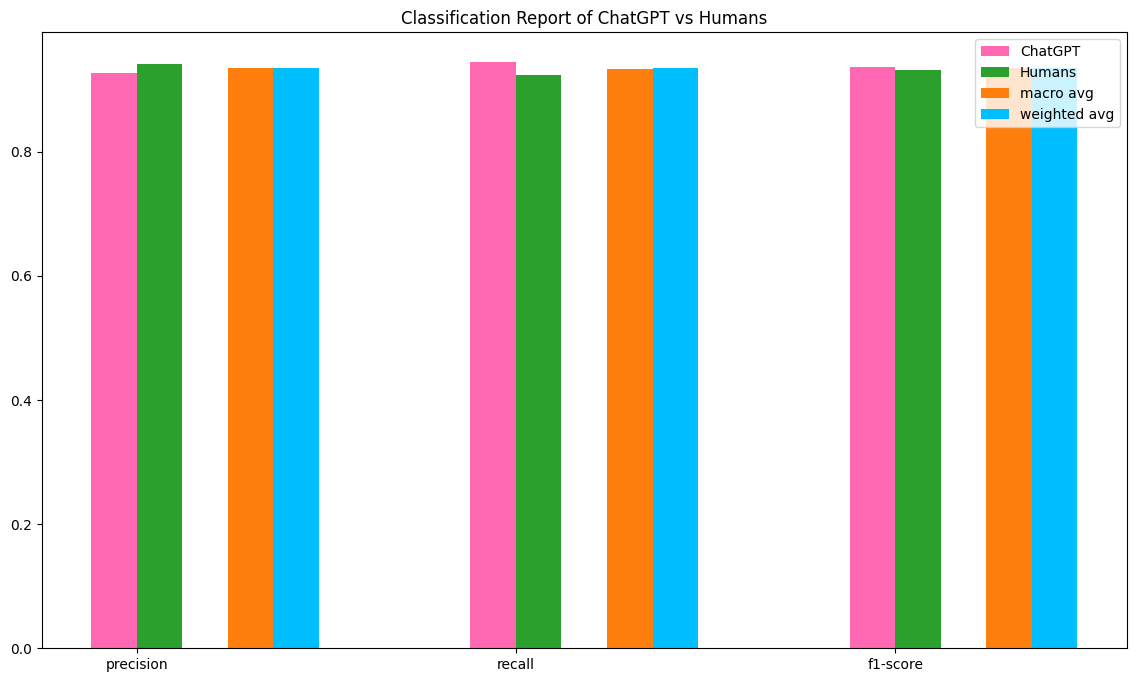

In [ ]:
mapping = {0:'chatgpt', 1:'human'}
print(classification_report(test_data2['label'], predictions,target_names = mapping.values()))
report = classification_report(test_data2['label'], predictions, output_dict=True)
print("report: ",report)

rep = ('precision', 'recall', 'f1-score')
class_rep_dict = {
    'ChatGPT': np.array([report['0'][metric] for metric in rep]),
    'Humans': np.array([report['1'][metric] for metric in rep]),
    'accuracy': np.array([report['accuracy']]),
    'macro avg': np.array([report['macro avg'][metric] for metric in rep]),
    'weighted avg': np.array([report['weighted avg'][metric] for metric in rep])
}

width = 0.6

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#ff69b4', '#2ca02c', '#ffd700', '#ff7f0e', '#00bfff']

x = np.arange(len(rep))
for i, (c, values) in enumerate(class_rep_dict.items()):
    if len(values) == len(rep):
        ax.bar(x + i * width/len(class_rep_dict), values, width/len(class_rep_dict), label=c, color=colors[i % len(colors)])

ax.set_xticks(x + width / (2 * len(class_rep_dict)))
ax.set_xticklabels(rep)
ax.set_title('Classification Report of ChatGPT vs Humans')
ax.legend()

plt.show()

**CONSIDERAZIONI** Il modello mostra un'elevata accuratezza generale (93%) nella classificazione tra "chatgpt" e "human".
Le metriche di precisione sono entrambe elevate per entrambe le classi (chatgpt 0.95 e human 0.92), questo mette in luce che il modello è bilanciato e performa bene sia nel riconoscere correttamente le istanze di "chatgpt" che quelle di "human". Il modello avrebbe potuto avere anche un accuratezza maggiore se si fosse utilizzato tutto il dataset perchè ovviamente più dati vengono sottoposti al modello più la sua accuracy sarà alta.